In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
train_df = pd.read_csv('sign_mnist_train.csv')
test_df = pd.read_csv('sign_mnist_test.csv')

In [3]:
train_df.shape

(27455, 785)

In [4]:
test_df.shape

(7172, 785)

In [5]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [6]:
y_train = train_df['label'].values

In [7]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [8]:
y_test = test_df['label'].values

In [9]:
y_test[:20]

array([ 6,  5, 10,  0,  3, 21, 10, 14,  3,  7,  8,  8, 21, 12,  7,  4, 22,
        0,  7,  7], dtype=int64)

In [10]:
X_train = train_df.drop('label', axis=1).values
X_test = test_df.drop('label', axis=1).values

In [11]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [12]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [13]:
unique_labels = sorted(np.unique(np.concatenate([y_train, y_test])))

In [14]:
label_map = {old: new for new, old in enumerate(unique_labels)}
label_map

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 10: 9,
 11: 10,
 12: 11,
 13: 12,
 14: 13,
 15: 14,
 16: 15,
 17: 16,
 18: 17,
 19: 18,
 20: 19,
 21: 20,
 22: 21,
 23: 22,
 24: 23}

In [15]:
y_train = np.array([label_map[y] for y in y_train])
y_test = np.array([label_map[y] for y in y_test])

In [16]:
len(unique_labels)

24

In [17]:
num_classes = len(unique_labels)
num_classes

24

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
    
plt.tight_layout()
plt.savefig('sample_images.png')
plt.close()
print("Sample images saved as 'sample_images.png'.")

Sample images saved as 'sample_images.png'.


In [19]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10


194/194 [==============================] - 11s 31ms/step - loss: 2.3715 - accuracy: 0.2729 - val_loss: 1.1256 - val_accuracy: 0.6835
Epoch 2/10
194/194 [==============================] - 6s 29ms/step - loss: 1.1615 - accuracy: 0.6141 - val_loss: 0.5413 - val_accuracy: 0.8281
Epoch 3/10
194/194 [==============================] - 5s 25ms/step - loss: 0.7295 - accuracy: 0.7526 - val_loss: 0.2525 - val_accuracy: 0.9374
Epoch 4/10
194/194 [==============================] - 5s 25ms/step - loss: 0.4943 - accuracy: 0.8280 - val_loss: 0.1693 - val_accuracy: 0.9559
Epoch 5/10
194/194 [==============================] - 5s 25ms/step - loss: 0.3838 - accuracy: 0.8679 - val_loss: 0.0971 - val_accuracy: 0.9807
Epoch 6/10
194/194 [==============================] - 5s 27ms/step - loss: 0.2904 - accuracy: 0.8972 - val_loss: 0.0511 - val_accuracy: 0.9891
Epoch 7/10
194/194 [==============================] - 5s 25ms/step - loss: 0.2256 - accuracy: 0.9221 - val_loss: 0.0323 - val_accuracy: 0.9

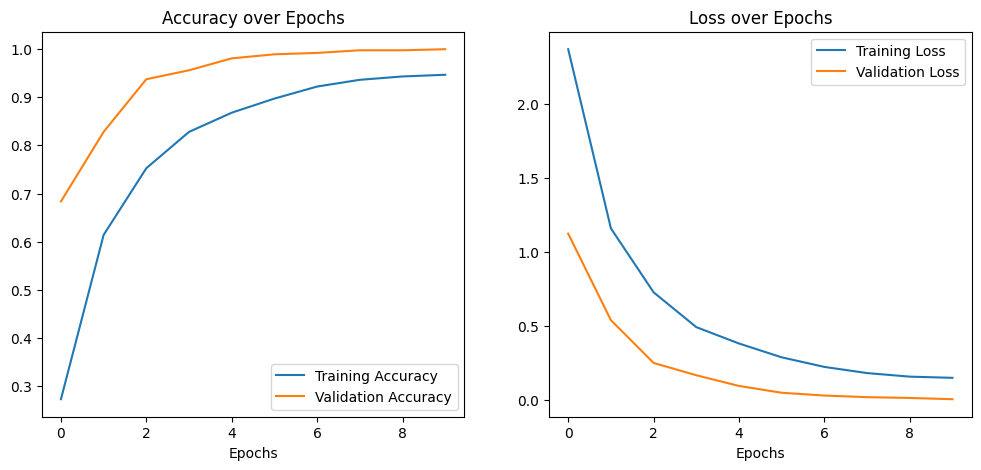

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epochs')
ax1.legend()

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epochs')
ax2.legend()

In [23]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

225/225 [==============================] - 2s 8ms/step - loss: 0.2229 - accuracy: 0.9343
Test Loss: 0.2229, Test Accuracy: 0.9343


In [24]:
model.predict(X_test)

225/225 [==============================] - 2s 8ms/step


array([[1.8053729e-16, 6.3844804e-17, 6.2652812e-06, ..., 1.8064858e-12,
        1.1513378e-05, 1.6017485e-13],
       [3.1307676e-10, 1.6831678e-04, 1.2309061e-15, ..., 9.9779107e-03,
        5.8724314e-09, 3.3101554e-07],
       [1.0140786e-26, 1.4586416e-19, 2.5399824e-22, ..., 5.3405097e-15,
        9.0483017e-11, 4.0001915e-08],
       ...,
       [3.9856978e-25, 2.0363895e-22, 9.9996209e-01, ..., 6.5755822e-28,
        9.6713265e-15, 2.2784408e-36],
       [2.2766957e-17, 8.3493319e-08, 8.6241648e-12, ..., 4.3352851e-13,
        1.4574546e-10, 7.5001115e-31],
       [1.2807769e-26, 7.7897111e-24, 9.9998236e-01, ..., 1.5065160e-29,
        9.7276091e-16, 3.3824192e-38]], dtype=float32)

In [25]:
y_pred = np.argmax(model.predict(X_test), axis=1)

225/225 [==============================] - 2s 9ms/step


In [26]:
y_pred

array([6, 5, 9, ..., 2, 4, 2], dtype=int64)

In [27]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[331   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0 401   0  14   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0  17   0   0]
 [  0   0 310   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0 244   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   1   0]
 [  0   0   0   0 489   0   0   0   0   0   0   0   0   0   0   0   0   9
    0   0   0   0   0   0]
 [  0   0   0   0   0 247   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0 280  25   0   0   0   0   0   0  10  28   0   0
    5   0   0   0   0   0]
 [  0   0   0   0   0   0  20 416   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 277   0   0   0   0   0   0   0   0   0
    0   0   1   0   0  10]
 [  0   0   0   0   0   0   0   0  16 295   0   0   0   0   0   0   1   0
    0  18   0   0

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.savefig('confusion_matrix.png')
plt.close()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       331
           1       1.00      0.93      0.96       432
           2       1.00      1.00      1.00       310
           3       0.95      1.00      0.97       245
           4       0.92      0.98      0.95       498
           5       1.00      1.00      1.00       247
           6       0.93      0.80      0.86       348
           7       0.86      0.95      0.91       436
           8       0.88      0.96      0.92       288
           9       1.00      0.89      0.94       331
          10       0.91      1.00      0.95       209
          11       0.90      0.94      0.92       394
          12       1.00      0.74      0.85       291
          13       1.00      0.89      0.94       246
          14       0.97      1.00      0.98       347
          15       0.85      1.00      0.92       164
          16       0.95      0.85      0.90       144
          17       0.92    

In [30]:
model.save('sign_language_cnn.keras')

In [31]:
from tensorflow.keras.models import load_model
model = load_model('sign_language_cnn.keras')

In [32]:
sample_idx = 0

sample_image = X_test[sample_idx : sample_idx + 1]
prediction = model.predict(sample_image)
predicted_class = np.argmax(prediction)

1/1 [==============================] - 0s 232ms/step


In [33]:
print(f'Demp prediction on test image # {sample_idx}')
print(f"True label index : {y_test[sample_idx]}, Predicted label index: {predicted_class}")

Demp prediction on test image # 0
True label index : 6, Predicted label index: 6


In [34]:
print(f"Confidence scores for each class: {prediction[0][predicted_class]}")

Confidence scores for each class: 0.9999778270721436


In [35]:
!pip install keras-tuner

In [36]:
import keras_tuner as kt 
from tensorflow.keras import layers, models 
from tensorflow.keras.optimizers import Adam

In [38]:
def build_model(hp):
    model = models.Sequential()
    
    # First convolutional layer
    model.add(
        layers.Conv2D(
            filters = hp.Choice('conv_1_filters', values=[32, 64]),
            kernel_size = (3,3),
            activation='relu',
            input_shape=(28, 28, 1)
        )
    )
    
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Second convolutional layer
    model.add(
        layers.Conv2D(
            filters = hp.Choice('conv_2_filters', values=[64, 128]),
            kernel_size = (3,3),
            activation='relu'
        )
    )
    
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Third convolutional layer
    model.add(
        layers.Conv2D(
            filters = hp.Choice('conv_3_filters', values=[64, 128]),
            kernel_size = (3,3),
            activation='relu'
        )
    )
    
    model.add(layers.Flatten())
    
    # Dense layer
    model.add(
        layers.Dense(
            units = hp.Choice('dense_units', values=[64, 128, 256]),
            activation='relu'
        )
    )
    
    # Dropout layer
    model.add(
        layers.Dropout(
            hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
        )
    )
    
    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    # Learning rate
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [39]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='sign_language_cnn'
)

In [40]:
tuner.search(X_train, y_train, epochs=10, validation_split=0.1, batch_size=128)

Trial 5 Complete [00h 01m 20s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 08m 37s


In [41]:
best_hp = tuner.get_best_hyperparameters(1)[0]

In [42]:
print("Best Hyperparameters:")
print(f"Conv Layer 1 Filters: {best_hp.get('conv_1_filters')}")
print(f"Conv Layer 2 Filters: {best_hp.get('conv_2_filters')}")
print(f"Conv Layer 3 Filters: {best_hp.get('conv_3_filters')}")
print(f"Dense Layer Units: {best_hp.get('dense_units')}")
print(f"Dropout Rate: {best_hp.get('dropout_rate')}")
print(f"Learning Rate: {best_hp.get('learning_rate')}")

Best Hyperparameters:
Conv Layer 1 Filters: 64
Conv Layer 2 Filters: 64
Conv Layer 3 Filters: 128
Dense Layer Units: 64
Dropout Rate: 0.2
Learning Rate: 0.001


In [43]:
best_model = tuner.hypermodel.build(best_hp)

In [44]:
history = best_model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=128
)

Epoch 1/10
194/194 [==============================] - 10s 39ms/step - loss: 2.1238 - accuracy: 0.3487 - val_loss: 0.7896 - val_accuracy: 0.7473
Epoch 2/10
194/194 [==============================] - 7s 36ms/step - loss: 0.6832 - accuracy: 0.7686 - val_loss: 0.2606 - val_accuracy: 0.9319
Epoch 3/10
194/194 [==============================] - 7s 36ms/step - loss: 0.3269 - accuracy: 0.8883 - val_loss: 0.0906 - val_accuracy: 0.9854
Epoch 4/10
194/194 [==============================] - 7s 36ms/step - loss: 0.1736 - accuracy: 0.9432 - val_loss: 0.0340 - val_accuracy: 0.9949
Epoch 5/10
194/194 [==============================] - 7s 36ms/step - loss: 0.1053 - accuracy: 0.9684 - val_loss: 0.0169 - val_accuracy: 0.9985
Epoch 6/10
194/194 [==============================] - 7s 36ms/step - loss: 0.0788 - accuracy: 0.9765 - val_loss: 0.0190 - val_accuracy: 0.9978
Epoch 7/10
194/194 [==============================] - 7s 36ms/step - loss: 0.0549 - accuracy: 0.9830 - val_loss: 0.0061 - val_accuracy: 0.999

In [45]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

225/225 [==============================] - 2s 9ms/step - loss: 0.4055 - accuracy: 0.9250
Test Loss: 0.4055, Test Accuracy: 0.9250
